# Memory Agent

## Review

We created a chatbot that saves semantic memories to a single [user profile](https://docs.langchain.com/oss/python/concepts/memory#profile) or [collection](https://docs.langchain.com/oss/python/concepts/memory#collection).

We introduced [Trustcall](https://github.com/hinthornw/trustcall) as a way to update either schema.

## Goals

Now, we're going to pull together the pieces we've learned to build an agent with long-term memory.

Our agent, `task_mAIstro`, will help us manage a ToDo list! 

The chatbots we built previously *always* reflected on the conversation and saved memories. 

`task_mAIstro` will decide *when* to save memories (items to our ToDo list).

The chatbots we built previously always saved one type of memory, a profile or a collection. 

`task_mAIstro` can decide to save to either a user profile or a collection of ToDo items.

In addition semantic memory, `task_mAIstro` also will manage procedural memory.

This allows the user to update their preferences for creating ToDo items. 

In [2]:
import os
from dotenv import load_dotenv

# Expand the tilde (~) to the full /home/user path
env_path = os.path.expanduser("~/.langchain.env")

# Load the file using the absolute path
load_dotenv(dotenv_path=env_path)

# Now you can access it like a normal environment variable
openai_api_key = os.getenv("OPENAI_API_KEY")
print(f"Current Working Directory: {os.getcwd()}")
print(f"Files in directory: {os.listdir('.')}")
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found. Check your .env file!")

print("API Key loaded successfully.")

Current Working Directory: /home/mario-useche/workspace/repos/others/langchain-academy/module-5
Files in directory: ['memory_agent.ipynb', 'memory_store.ipynb', 'studio', 'memoryschema_collection.ipynb', 'memoryschema_profile.ipynb', 'LangChain_Academy_-_Introduction_to_LangGraph_-_Long-Term_Memory.pdf']
API Key loaded successfully.


## Visibility into Trustcall updates

Trustcall creates and updates JSON schemas.

What if we want visibility into the *specific changes* made by Trustcall?

For example, we saw before that Trustcall has some of its own tools to:

* Self-correct from validation failures -- [see trace example here](https://smith.langchain.com/public/5cd23009-3e05-4b00-99f0-c66ee3edd06e/r/9684db76-2003-443b-9aa2-9a9dbc5498b7) 
* Update existing documents -- [see trace example here](https://smith.langchain.com/public/f45bdaf0-6963-4c19-8ec9-f4b7fe0f68ad/r/760f90e1-a5dc-48f1-8c34-79d6a3414ac3)

Visibility into these tools can be useful for the agent we're going to build.

Below, we'll show how to do this!

In [3]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user.")

We can add a [listener](https://python.langchain.com/docs/how_to/lcel_cheatsheet/#add-lifecycle-listeners) <!-- broken, but cannot find better linke --> to the Trustcall extractor.

This will pass runs from the extractor's execution to a class, `Spy`, that we will define.

Our `Spy` class will extract information about what tool calls were made by Trustcall.

In [4]:
from trustcall import create_extractor
from langchain_openai import ChatOpenAI

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

# Add the spy as a listener
trustcall_extractor_see_all_tool_calls = trustcall_extractor.with_listeners(on_end=spy)

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# Instruction
instruction = """Extract memories from the following conversation:"""

# Conversation
conversation = [HumanMessage(content="Hola soy Mario."), 
                AIMessage(content="Encantado de conocerte, Mario."), 
                HumanMessage(content="Esta ma~nana fui a caminar por el borde del Aare en Berna."),]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [6]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_OYR9HROVeoV1flWG5gXFdzGP)
 Call ID: call_OYR9HROVeoV1flWG5gXFdzGP
  Args:
    content: Mario went for a walk along the Aare River in Bern this morning.


In [7]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content='Mario went for a walk along the Aare River in Bern this morning.'


In [8]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_OYR9HROVeoV1flWG5gXFdzGP'}


In [9]:
# Update the conversation
updated_conversation = [AIMessage(content="Genial. Que hiciste despues?"), 
                        HumanMessage(content="Fui a un café cercano, me gusta ir a cafés."),                        
                        AIMessage(content="Que otra cosa te pasa por la mente?"),
                        HumanMessage(content="Estaba pensando en ir a visitar a mi amiga a Ginebra"),]

# Update the instruction
system_msg = """Update existing memories and create new ones based on the following conversation:"""

# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

[('0',
  'Memory',
  {'content': 'Mario went for a walk along the Aare River in Bern this morning.'})]

In [10]:
# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor_see_all_tool_calls.invoke({"messages": updated_conversation, 
                                                        "existing": existing_memories})

In [11]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_W0LY9LhY22bgSQMt3qUD1ZJl', 'json_doc_id': '0'}
{'id': 'call_Ua9JGlR0Ib8swqpQFVVx9mrD'}


In [12]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_W0LY9LhY22bgSQMt3qUD1ZJl)
 Call ID: call_W0LY9LhY22bgSQMt3qUD1ZJl
  Args:
    content: Mario went for a walk along the Aare River in Bern this morning. Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.
  Memory (call_Ua9JGlR0Ib8swqpQFVVx9mrD)
 Call ID: call_Ua9JGlR0Ib8swqpQFVVx9mrD
  Args:
    content: Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.


In [13]:
# Parsed responses
for m in result["responses"]:
    print(m)

content='Mario went for a walk along the Aare River in Bern this morning. Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.'
content='Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.'


In [14]:
# Inspect the tool calls made by Trustcall
spy.called_tools

[[{'name': 'PatchDoc',
   'args': {'json_doc_id': '0',
    'planned_edits': 'Add the new memory content about going to a café and thinking about visiting a friend in Geneva to the existing memory instance.',
    'patches': [{'op': 'replace',
      'path': '/content',
      'value': 'Mario went for a walk along the Aare River in Bern this morning. Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.'}]},
   'id': 'call_W0LY9LhY22bgSQMt3qUD1ZJl',
   'type': 'tool_call'},
  {'name': 'Memory',
   'args': {'content': 'Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.'},
   'id': 'call_Ua9JGlR0Ib8swqpQFVVx9mrD',
   'type': 'tool_call'}]]

In [15]:
def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.
    
    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []
    
    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )
    
    return "\n\n".join(result_parts)

# Inspect spy.called_tools to see exactly what happened during the extraction
schema_name = "Memory"
changes = extract_tool_info(spy.called_tools, schema_name)
print(changes)

Document 0 updated:
Plan: Add the new memory content about going to a café and thinking about visiting a friend in Geneva to the existing memory instance.
Added content: Mario went for a walk along the Aare River in Bern this morning. Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.

New Memory created:
Content: {'content': 'Then, he went to a nearby café, as he enjoys visiting cafés. He was also thinking about visiting his friend in Geneva.'}


## Creating an agent

There are many different agent architectures to choose from.

Here, we'll implement something simple, a [ReAct](https://docs.langchain.com/oss/python/langgraph/workflows-agents#agents) agent.

This agent will be a helpful companion for creating and managing a ToDo list.

This agent can make a decision to update three types of long-term memory: 

(a) Create or update a user `profile` with general user information 

(b) Add or update items in a ToDo list `collection`

(c) Update its own `instructions` on how to update items to the ToDo list

In [16]:
from typing import TypedDict, Literal

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'todo', 'instructions']

## Graph definition 

We add a simple router, `route_message`, that makes a binary decision to save memories.

The memory collection updating is handled by `Trustcall` in the `write_memory` node, as before!

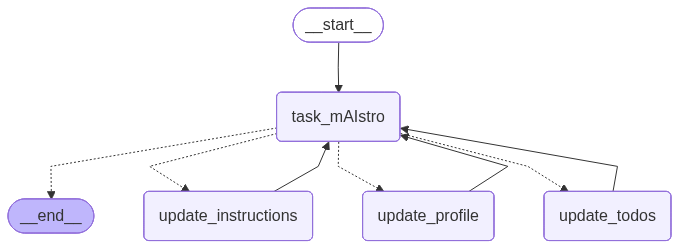

In [18]:
import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
from typing import Optional
from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langchain_openai import ChatOpenAI

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    connections: list[str] = Field(
        description="Personal connection of the user, such as family members, friends, or coworkers",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has", 
        default_factory=list
    )

# ToDo schema
class ToDo(BaseModel):
    task: str = Field(description="The task to be completed.")
    time_to_complete: Optional[int] = Field(description="Estimated time to complete the task (minutes).")
    deadline: Optional[datetime] = Field(
        description="When the task needs to be completed by (if applicable)",
        default=None
    )
    solutions: list[str] = Field(
        description="List of specific, actionable solutions (e.g., specific ideas, service providers, or concrete options relevant to completing the task)",
        min_length=1,
        default_factory=list
    )
    status: Literal["not started", "in progress", "done", "archived"] = Field(
        description="Current status of the task",
        default="not started"
    )

# Create the Trustcall extractor for updating the user profile 
profile_extractor = create_extractor(
    model,
    tools=[Profile],
    tool_choice="Profile",
)

# Chatbot instruction for choosing what to update and what tools to call 
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. 

You are designed to be a companion to a user, helping them keep track of their ToDo list.

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them) 
2. The user's ToDo list
3. General instructions for updating the ToDo list

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current ToDo List (may be empty if no tasks have been added yet):
<todo>
{todo}
</todo>

Here are the current user-specified preferences for updating the ToDo list (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below. 

2. Decide whether any of the your long-term memory should be updated:
- If personal information was provided about the user, update the user's profile by calling UpdateMemory tool with type `user`
- If tasks are mentioned, update the ToDo list by calling UpdateMemory tool with type `todo`
- If the user has specified preferences for how to update the ToDo list, update the instructions by calling UpdateMemory tool with type `instructions`

3. Tell the user that you have updated your memory, if appropriate:
- Do not tell the user you have updated the user's profile
- Tell the user them when you update the todo list
- Do not tell the user that you have updated instructions

4. Err on the side of updating the todo list. No need to ask for explicit permission.

5. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made."""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

# Instructions for updating the ToDo list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update ToDo list items. 

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""

# Node definitions
def task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve profile memory from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    # Retrieve task memory from the store
    namespace = ("todo", user_id)
    memories = store.search(namespace)
    todo = "\n".join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = ""
    
    system_msg = MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile, todo=todo, instructions=instructions)

    # Respond using memory as well as the chat history
    response = model.bind_tools([UpdateMemory], parallel_tool_calls=False).invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": [response]}

def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("profile", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Profile"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Invoke the extractor
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

def update_todos(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("todo", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "ToDo"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()
    
    # Create the Trustcall extractor for updating the ToDo list 
    todo_extractor = create_extractor(
    model,
    tools=[ToDo],
    tool_choice=tool_name,
    enable_inserts=True
    ).with_listeners(on_end=spy)

    # Invoke the extractor
    result = todo_extractor.invoke({"messages": updated_messages, 
                                    "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
        
    # Respond to the tool call made in task_mAIstro, confirming the update
    tool_calls = state['messages'][-1].tool_calls

    # Extract the changes made by Trustcall and add the the ToolMessage returned to task_mAIstro
    todo_update_msg = extract_tool_info(spy.called_tools, tool_name)
    return {"messages": [{"role": "tool", "content": todo_update_msg, "tool_call_id":tool_calls[0]['id']}]}

def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]
    
    namespace = ("instructions", user_id)

    existing_memory = store.get(namespace, "user_instructions")
        
    # Format the memory in the system prompt
    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store 
    key = "user_instructions"
    store.put(namespace, key, {"memory": new_memory.content})
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}

# Conditional edge
def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> Literal[END, "update_todos", "update_instructions", "update_profile"]:

    """Reflect on the memories and chat history to decide whether to update the memory collection."""
    message = state['messages'][-1]
    if len(message.tool_calls) ==0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['args']['update_type'] == "user":
            return "update_profile"
        elif tool_call['args']['update_type'] == "todo":
            return "update_todos"
        elif tool_call['args']['update_type'] == "instructions":
            return "update_instructions"
        else:
            raise ValueError

# Create the graph + all nodes
builder = StateGraph(MessagesState)

# Define the flow of the memory extraction process
builder.add_node(task_mAIstro)
builder.add_node(update_todos)
builder.add_node(update_profile)
builder.add_node(update_instructions)
builder.add_edge(START, "task_mAIstro")
builder.add_conditional_edges("task_mAIstro", route_message)
builder.add_edge("update_todos", "task_mAIstro")
builder.add_edge("update_profile", "task_mAIstro")
builder.add_edge("update_instructions", "task_mAIstro")

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# We compile the graph with the checkpointer and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [19]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "Mario"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="Me llamo Mario. Vivo en Berna con mis dos hijos de 10 y 12 anos")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Me llamo Mario. Vivo en Berna con mis dos hijos de 10 y 12 anos
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_lxzGvqrjvt1N6T5Kr6R4AOC6)
 Call ID: call_lxzGvqrjvt1N6T5Kr6R4AOC6
  Args:
    update_type: user
================================= Tool Message =================================

updated profile
================================== Ai Message ==================================

¡Hola, Mario! Encantado de conocerte. Si necesitas ayuda con algo o quieres añadir tareas a tu lista de pendientes, aquí estoy para ayudarte.


In [20]:
# User input for a ToDo
input_messages = [HumanMessage(content="Me gustaria agregar a mi lista de cosas por hacer: comprar un regalo para el cumpleanos de mi hijo el proximo sabado")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Me gustaria agregar a mi lista de cosas por hacer: comprar un regalo para el cumpleanos de mi hijo el proximo sabado
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_zTKCONg9AodpVE3SO1M2GM7G)
 Call ID: call_zTKCONg9AodpVE3SO1M2GM7G
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Comprar un regalo para el cumpleaños de mi hijo', 'time_to_complete': 60, 'deadline': '2026-04-04T00:00:00', 'solutions': ['Visitar una tienda de juguetes en Berna', 'Consultar tiendas en línea como Amazon', 'Preguntar a mi hijo sobre sus intereses actuales'], 'status': 'not started'}
================================== Ai Message ==================================

He añadido la tarea de comprar un regalo para el cumpleaños de tu hijo a tu lista de cosas por hacer. Si

In [21]:
# User input to update instructions for creating ToDos
input_messages = [HumanMessage(content="When creating or updating ToDo items, include specific local businesses / vendors.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

When creating or updating ToDo items, include specific local businesses / vendors.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_wXsP8lWk2ApOQAIlsRuuhOoA)
 Call ID: call_wXsP8lWk2ApOQAIlsRuuhOoA
  Args:
    update_type: instructions
================================= Tool Message =================================

updated instructions
================================== Ai Message ==================================

He actualizado tus preferencias para incluir negocios o proveedores locales específicos al crear o actualizar elementos de la lista de tareas. Si necesitas algo más, aquí estoy para ayudarte.


In [22]:
# Check for updated instructions
user_id = "Mario"

# Search 
for memory in across_thread_memory.search(("instructions", user_id)):
    print(memory.value)

{'memory': "<current_instructions>\nWhen creating or updating ToDo items, include specific local businesses or vendors relevant to the user's location or preferences. For example, if the user is in Berna, suggest local toy stores or online options like Amazon for purchasing gifts.\n</current_instructions>"}


In [23]:
# User input for a ToDo
input_messages = [HumanMessage(content="Necesito planificar las visitas del apartamento que voy a dejar.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Necesito planificar las visitas del apartamento que voy a dejar.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_HioYYxWj7y5LbxZnkoLoY7mm)
 Call ID: call_HioYYxWj7y5LbxZnkoLoY7mm
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Planificar las visitas del apartamento que voy a dejar', 'time_to_complete': 120, 'solutions': ['Contactar a la agencia inmobiliaria para coordinar horarios', 'Preparar el apartamento para las visitas', 'Hacer un calendario de visitas', 'Informar a los vecinos sobre las visitas']}

Document 23209baa-c2cb-463d-89c1-e0279fcd52a5 updated:
Plan: Add specific local businesses or vendors to the solutions list for buying a gift.
Added content: Juguetería Spielzeug24 en Berna
================================== Ai Message =====

In [28]:
# Namespace for the memory to save
user_id = "Mario"

# Search 
for memory in across_thread_memory.search(("todo", user_id)):
    print(memory.value)

{'task': 'Comprar un regalo para el cumpleaños de mi hijo', 'time_to_complete': 60, 'deadline': '2026-04-04T00:00:00', 'solutions': ['Visitar una tienda de juguetes en Berna', 'Consultar tiendas en línea como Amazon', 'Preguntar a mi hijo sobre sus intereses actuales', 'Juguetería Spielzeug24 en Berna', 'Tienda de regalos Berna Gifts'], 'status': 'not started'}
{'task': 'Planificar las visitas del apartamento que voy a dejar', 'time_to_complete': 120, 'deadline': '2026-04-07T00:00:00', 'solutions': ['Contactar a la agencia inmobiliaria para coordinar horarios', 'Preparar el apartamento para las visitas', 'Hacer un calendario de visitas', 'Informar a los vecinos sobre las visitas'], 'status': 'not started'}


In [27]:
# User input to update an existing ToDo
input_messages = [HumanMessage(content="Para las visitas de apartamento, necesito planfificar esto la proxima semana")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Para las visitas de apartamento, necesito planfificar esto la proxima semana
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_M4quScrefx3hkHcIeZRX8rVj)
 Call ID: call_M4quScrefx3hkHcIeZRX8rVj
  Args:
    update_type: todo
================================= Tool Message =================================

Document 24ed6554-6b13-472e-aa41-200a72b29522 updated:
Plan: Add a deadline for planning the apartment visits to next week.
Added content: 2026-04-07T00:00:00
================================== Ai Message ==================================

He actualizado la tarea para planificar las visitas del apartamento, estableciendo la fecha límite para la próxima semana. Si necesitas algo más, aquí estoy para ayudarte.


We can see that Trustcall performs patching of the existing memory:

https://smith.langchain.com/public/4ad3a8af-3b1e-493d-b163-3111aa3d575a/r

In [29]:
# User input for a ToDo
input_messages = [HumanMessage(content="Necesito cambiar los frenos de mi Lexus y tambien comprar nuevas ruedas de invierno")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Necesito cambiar los frenos de mi Lexus y tambien comprar nuevas ruedas de invierno
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_TiWUuTqBuWAtxslraVDaEfuB)
 Call ID: call_TiWUuTqBuWAtxslraVDaEfuB
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Cambiar los frenos de mi Lexus', 'time_to_complete': 180, 'solutions': ['Visitar el taller mecánico AutoService Berna', 'Consultar con el concesionario Lexus en Berna', 'Revisar opciones de talleres en línea'], 'status': 'not started'}

New ToDo created:
Content: {'task': 'Comprar nuevas ruedas de invierno para mi Lexus', 'time_to_complete': 60, 'solutions': ['Visitar la tienda de neumáticos ReifenDirekt en Berna', 'Consultar tiendas en línea como Tirendo', 'Preguntar en el concesionario Lexus sobre 

In [30]:
# Namespace for the memory to save
user_id = "Mario"

# Search 
for memory in across_thread_memory.search(("todo", user_id)):
    print(memory.value)

{'task': 'Comprar un regalo para el cumpleaños de mi hijo', 'time_to_complete': 60, 'deadline': '2026-04-04T00:00:00', 'solutions': ['Visitar una tienda de juguetes en Berna', 'Consultar tiendas en línea como Amazon', 'Preguntar a mi hijo sobre sus intereses actuales', 'Juguetería Spielzeug24 en Berna', 'Tienda de regalos Berna Gifts'], 'status': 'not started'}
{'task': 'Planificar las visitas del apartamento que voy a dejar', 'time_to_complete': 120, 'deadline': '2026-04-07T00:00:00', 'solutions': ['Contactar a la agencia inmobiliaria para coordinar horarios', 'Preparar el apartamento para las visitas', 'Hacer un calendario de visitas', 'Informar a los vecinos sobre las visitas'], 'status': 'not started'}
{'task': 'Cambiar los frenos de mi Lexus', 'time_to_complete': 180, 'deadline': None, 'solutions': ['Visitar el taller mecánico AutoService Berna', 'Consultar con el concesionario Lexus en Berna', 'Revisar opciones de talleres en línea'], 'status': 'not started'}
{'task': 'Comprar nu

Now we can create a new thread.

This creates a new session. 

Profile, ToDos, and Instructions saved to long-term memory are accessed. 

In [34]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": str(uuid.uuid4()), "user_id": "Mario"}}

# Chat with the chatbot
input_messages = [HumanMessage(content="Tengo dos horas libres. Que puedo hacer?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Tengo dos horas libres. Que puedo hacer?
================================== Ai Message ==================================

Tienes varias tareas en tu lista de ToDo que podrías considerar:

1. **Planificar las visitas del apartamento que vas a dejar**: Esta tarea tiene un tiempo estimado de 120 minutos, lo cual encaja perfectamente con tus dos horas libres. Podrías contactar a la agencia inmobiliaria para coordinar horarios, preparar el apartamento para las visitas, hacer un calendario de visitas, e informar a los vecinos sobre las visitas.

2. **Cambiar los frenos de tu Lexus**: Aunque esta tarea tiene un tiempo estimado de 180 minutos, podrías comenzar a investigar opciones o hacer una cita en el taller mecánico AutoService Berna o consultar con el concesionario Lexus en Berna.

3. **Comprar nuevas ruedas de invierno para tu Lexus**: Esta tarea tiene un tiempo estimado de 60 minutos, por lo que podrías c

In [35]:
# Chat with the chatbot
input_messages = [HumanMessage(content="Si, mira en mi agenda que dias tengo libre para las visitas del apartamento")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Si, mira en mi agenda que dias tengo libre para las visitas del apartamento
================================== Ai Message ==================================

Actualmente no tengo acceso a tu agenda personal para verificar tus días libres. Sin embargo, puedo sugerirte que revises tu calendario y busques días en los que tengas bloques de tiempo disponibles para coordinar las visitas del apartamento. Una vez que identifiques esos días, podrías contactar a la agencia inmobiliaria para coordinar los horarios y preparar el apartamento para las visitas.

Si necesitas ayuda para organizar las visitas o cualquier otra cosa, ¡déjame saber!


Trace: 

https://smith.langchain.com/public/84768705-be91-43e4-8a6f-f9d3cee93782/r

## Studio

![Screenshot 2024-11-04 at 1.00.19 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6732cfb05d9709862eba4e6c_Screenshot%202024-11-11%20at%207.46.40%E2%80%AFPM.png)